#### CARGA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_og = pd.read_csv('../data/raw/LAIS_public.csv')
df = df_og.copy() #criando cópia do dataframe original

df.info()


C:\Users\Andrew\AppData\Local\Temp\ipykernel_16944\836065809.py:1: DtypeWarning: Columns (12,16,245,246,247,248,249,250,252,253,254) have mixed types. Specify dtype option on import or set low_memory=False.
  df_og = pd.read_csv('../data/raw/LAIS_public.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119900 entries, 0 to 119899
Columns: 686 entries, country to coop_other_other
dtypes: float64(661), int64(10), object(15)
memory usage: 627.5+ MB


In [3]:
df.head()

,country,countryc,fucode,firm_id,exp_f,exp_f1,year,survey,year1,year2,...,coop_tert_other,coop_labRD_other,coop_lab_other,coop_privres_other,coop_pubres_other,coop_res_other,coop_ip_other,coop_pubsti_other,coop_gov_other,coop_other_other
0,Argentina,ARG,32100384.0,100384.0,3.236364,NaN,2013,ARG_2013,2010,2011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Argentina,ARG,32100464.0,100464.0,3.000000,NaN,2013,ARG_2013,2010,2011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Argentina,ARG,32100794.0,100794.0,5.701755,NaN,2013,ARG_2013,2010,2011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Argentina,ARG,32100882.0,100882.0,2.574074,NaN,2013,ARG_2013,2010,2011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,ARG,32100965.0,100965.0,4.586207,NaN,2013,ARG_2013,2010,2011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Criação das targets

In [4]:
#dinn = inovação de produtos(bens ou serviços) ou processos, novos ou melhorados
df['dinn'] = 0
df.dinnpd = df.dinnpd.astype('Int32')
df.dinnpc = df.dinnpc.astype('Int32')
df.loc[(df.dinnpd==1) | (df.dinnpc==1),'dinn']=1

In [5]:
target = 'dinn'#'dinnpd'#'dinnpc'#

In [6]:
features = ['country','fucode','exp_f','year','isic3_1d','isic3_2d','sales_us_Y1','sales_us_Y2','sales_us_Y3',
'export_us_Y1','export_us_Y2','export_us_Y3','dexport','empl_Y1','empl_Y2','empl_Y3','phd_Y1','phd_Y2','phd_Y3',
'master_Y1','master_Y2','master_Y3','postgrad_Y1','postgrad_Y2','postgrad_Y3','undergrad_Y1','undergrad_Y2','undergrad_Y3',
'unidegree_Y1','unidegree_Y2','unidegree_Y3','degree_nesc','degree_et','degree_ingnesc','degree_ssc','degree_medsc','degree_agrsc','degree_hum',
'nontert_Y1','nontert_Y2','nontert_Y3','second_Y1','second_Y2','second_Y3',
'RD_empl','ict_mach_us_Y1','IPexp_us_Y1','ict_mach_us_Y2','IPexp_us_Y2','drdintexp',
'drdextexp','dictexp','dmachexp','dict_mach','dTTexp','dconexp','dIPexp','dtrainexp','dIDexp','dmktexp','dongoingia','dabandia']

#### LIMPEZA INICIAL

In [7]:
def percentual_nulos(df):
    # verificando nulls no dataset
    total_null = df.isnull().sum().sort_values(ascending=False)
    percent_null = (total_null/df.shape[0]).sort_values(ascending=False)
    return percent_null

In [8]:
nulls_df = percentual_nulos(df)
df_edit = df.drop(nulls_df[nulls_df>0.50].index,axis=1)
target_index = df[target].dropna().index


target_df = df_edit.loc[target_index]
nulls_target = percentual_nulos(target_df)
df_target_og = target_df.drop(nulls_target[nulls_target>0.50].index,axis=1)


#### ANALISES

##### Por Ano

In [64]:
df = df_target_og.copy()

In [84]:
corrs = {}
for year in set(df.year):
    corrs[year] = df.query('year==@year').corr()['dinn'].sort_values(ascending=False)

In [101]:
corr_por_ano = pd.concat(corrs.values(),axis=1)
corr_por_ano.columns = corrs.keys()
corr_por_ano = corr_por_ano[corr_por_ano.columns.sort_values()]

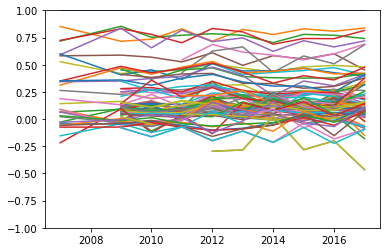

In [107]:
for i in corr_por_ano.index:
    plt.plot(corr_por_ano.columns,corr_por_ano.loc[i,:])
    plt.ylim([-1, 1])
    #plt.show()